<a href="https://colab.research.google.com/github/Nehasatheesh04/computer-vision/blob/main/computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement SIFT based image matching between 2 images and visualise the matched key points

In [ ]:
pip install opencv-contrib-python


In [ ]:
import urllib.request
import cv2
import matplotlib.pyplot as plt

# URLs for the standard OpenCV tutorial images
url1 = "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/box.png"
url2 = "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/box_in_scene.png"

# Download the images
urllib.request.urlretrieve(url1, "box.png")
urllib.request.urlretrieve(url2, "box_in_scene.png")

print("Images downloaded successfully as 'box.png' and 'box_in_scene.png'")

# Load and visualize to confirm
img1 = cv2.imread('box.png')
img2 = cv2.imread('box_in_scene.png')

Images downloaded successfully as 'box.png' and 'box_in_scene.png'


Keypoints in Image 1: 604
Keypoints in Image 2: 969
Good matches: 80


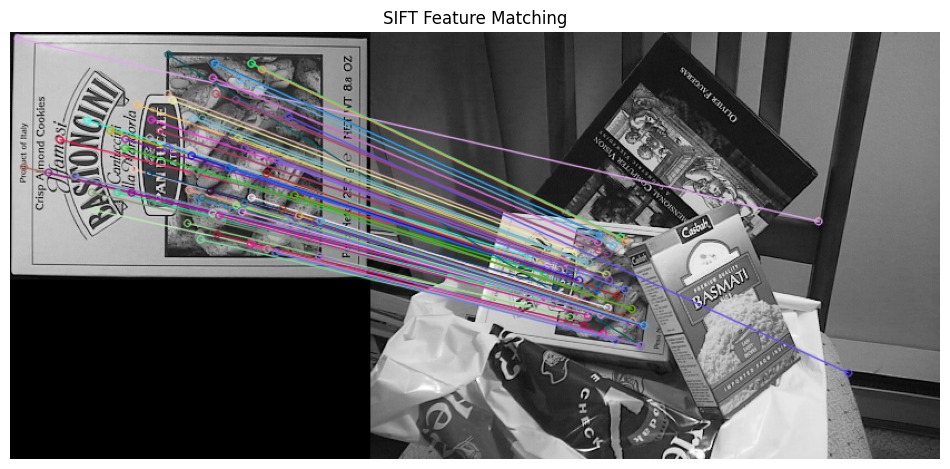

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. Read images (grayscale)
img1 = cv2.imread('/content/box.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/content/box_in_scene.png', cv2.IMREAD_GRAYSCALE)

# Check if images loaded
if img1 is None or img2 is None:
    print("Error loading images")
    exit()

# 2. Create SIFT object
sift = cv2.SIFT_create()

# 3. Detect keypoints and compute descriptors
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

print(f"Keypoints in Image 1: {len(kp1)}")
print(f"Keypoints in Image 2: {len(kp2)}")

# 4. Match descriptors using BFMatcher
bf = cv2.BFMatcher(cv2.NORM_L2)

matches = bf.knnMatch(des1, des2, k=2)

# 5. Apply Lowe's Ratio Test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print(f"Good matches: {len(good_matches)}")

# 6. Draw matched keypoints
matched_img = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# 7. Display result
plt.figure(figsize=(12,6))
plt.imshow(matched_img, cmap='gray')
plt.title('SIFT Feature Matching')
plt.axis('off')
plt.show()


Implement a pedestrian detection system using HOG and SVM and evaluate the accuracy

In [1]:
pip install opencv-python scikit-learn matplotlib -q


In [13]:
import cv2
import numpy as np
import os
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize HOG descriptor
hog = cv2.HOGDescriptor(
    _winSize=(64, 128),
    _blockSize=(16, 16),
    _blockStride=(8, 8),
    _cellSize=(8, 8),
    _nbins=9
)

In [14]:
# 2. Define the HOG feature extraction function
def extract_hog_features(folder, prefix=None):
    features = []
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

    for file in os.listdir(folder):
        if prefix and not file.startswith(prefix):
            continue
        if not file.lower().endswith(valid_extensions):
            continue

        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (64, 128))
        hog_features = hog.compute(img)
        features.append(hog_features.flatten())

    return features

In [15]:
# 3. Search for the training image folder recursively
def find_jpeg_folder_recursive(root_path):
    for root, dirs, files in os.walk(root_path):
        if 'JPEGImages' in dirs and 'train' in root.lower():
            return os.path.join(root, 'JPEGImages')
    return None

train_path = find_jpeg_folder_recursive('/content/')
print(f"Training folder located at: {train_path}")

Training folder located at: /content/drive/MyDrive/archive (3)/Train/JPEGImages


In [16]:
# 4. Load features for both classes (person and crop)
print("Extracting HOG features...")
pos_features = extract_hog_features(train_path, prefix="person")
neg_features = extract_hog_features(train_path, prefix="crop")

print(f"Loaded {len(pos_features)} positive samples and {len(neg_features)} negative samples.")

Extracting HOG features...
Loaded 209 positive samples and 405 negative samples.


In [17]:
# 5. Prepare data and train the Linear SVM model
X = np.array(pos_features + neg_features)
y = np.array([1]*len(pos_features) + [0]*len(neg_features))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training SVM model...")
svm = LinearSVC(max_iter=2000, dual=False)
svm.fit(X_train, y_train)

Training SVM model...


LinearSVC(dual=False, max_iter=2000)

In [18]:
# 6. Evaluate accuracy and print report
y_pred = svm.predict(X_test)
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Overall Accuracy: 0.7561

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.88      0.82        76
           1       0.74      0.55      0.63        47

    accuracy                           0.76       123
   macro avg       0.75      0.72      0.73       123
weighted avg       0.75      0.76      0.75       123

